# CIFAR-10 Starter: Cache + Train/Test/Validation Split

This notebook downloads CIFAR-10 once, caches 10,000 images locally, and then splits the cached dataset into train/test/validation sets.

Environment note: this project is managed with `uv` (`uv sync` to install/update dependencies).

## 1) Imports and Paths
Getting all the tools and setting up where to keep our data and cache.

In [55]:
# Import libraries and define reusable project paths.
from pathlib import Path
import tarfile
import pickle

import numpy as np

CIFAR10_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"

DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
CACHE_DIR = DATA_DIR / "cache"

ARCHIVE_PATH = RAW_DIR / "cifar-10-python.tar.gz"
EXTRACTED_DIR = RAW_DIR / "cifar-10-batches-py"
CACHE_PATH = CACHE_DIR / "cifar10_10000.npz"

CLASS_NAMES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

RAW_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

## 2) Helper Functions
Some utility functions to download, load, and split the data safely.

In [56]:
# Define reusable helpers for safe extraction and batch loading.
def _safe_extract(tar: tarfile.TarFile, path: Path) -> None:
    base = path.resolve()
    for member in tar.getmembers():
        member_path = (path / member.name).resolve()
        if not str(member_path).startswith(str(base)):
            raise RuntimeError(f"Unsafe path in tar file: {member.name}")
    tar.extractall(path=path)


def download_and_extract_cifar10() -> None:
    import urllib.request

    if EXTRACTED_DIR.exists():
        print(f"Dataset already extracted at: {EXTRACTED_DIR}")
        return

    if not ARCHIVE_PATH.exists():
        print("Downloading CIFAR-10 archive...")
        urllib.request.urlretrieve(CIFAR10_URL, ARCHIVE_PATH)
        print(f"Saved archive to: {ARCHIVE_PATH}")
    else:
        print(f"Archive already exists at: {ARCHIVE_PATH}")

    print("Extracting archive...")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        _safe_extract(tar, RAW_DIR)
    print(f"Extracted to: {EXTRACTED_DIR}")


def load_cifar_batch(batch_file: Path):
    with batch_file.open("rb") as f:
        batch = pickle.load(f, encoding="bytes")

    images = batch[b"data"]
    labels = np.array(batch[b"labels"], dtype=np.int64)

    images = images.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    return images, labels


def split_dataset(images: np.ndarray, labels: np.ndarray, train_ratio: float, test_ratio: float, val_ratio: float, seed: int = 42):
    ratio_sum = train_ratio + test_ratio + val_ratio
    if not np.isclose(ratio_sum, 1.0):
        raise ValueError(f"train_ratio + test_ratio + val_ratio must be 1.0, got {ratio_sum:.4f}")

    n = len(images)
    rng = np.random.default_rng(seed)
    indices = np.arange(n)
    rng.shuffle(indices)

    train_end = int(n * train_ratio)
    test_end = train_end + int(n * test_ratio)

    train_idx = indices[:train_end]
    test_idx = indices[train_end:test_end]
    val_idx = indices[test_end:]

    return {
        "X_train": images[train_idx],
        "y_train": labels[train_idx],
        "X_test": images[test_idx],
        "y_test": labels[test_idx],
        "X_val": images[val_idx],
        "y_val": labels[val_idx],
    }

## 3) Build or Load Cache and Split Data
Either grab the cached dataset or download CIFAR-10 once and cache 10k images locally. Then split it up for training and testing.

In [57]:
# Build or load 10,000-image cache, then split into train/test/validation sets.
TRAIN_RATIO = 0.7  # X%
TEST_RATIO = 0.2   # Y%
VAL_RATIO = 0.1    # Z%
SEED = 42

if CACHE_PATH.exists():
    print(f"Loading cached dataset from: {CACHE_PATH}")
    with np.load(CACHE_PATH) as cached:
        images = cached["images"]
        labels = cached["labels"]
        class_names = cached["class_names"].tolist()
else:
    print("Cache not found. Building cache from CIFAR-10...")
    download_and_extract_cifar10()

    # data_batch_1 contains exactly 10,000 training images
    batch_file = EXTRACTED_DIR / "data_batch_1"
    images, labels = load_cifar_batch(batch_file)
    class_names = CLASS_NAMES

    np.savez_compressed(
        CACHE_PATH,
        images=images.astype(np.uint8),
        labels=labels.astype(np.int64),
        class_names=np.array(class_names),
    )
    print(f"Cache saved to: {CACHE_PATH}")

splits = split_dataset(images, labels, TRAIN_RATIO, TEST_RATIO, VAL_RATIO, seed=SEED)

X_train, y_train = splits["X_train"], splits["y_train"]
X_test, y_test = splits["X_test"], splits["y_test"]
X_val, y_val = splits["X_val"], splits["y_val"]

print("Done.")
print(f"images shape: {images.shape}")
print(f"labels shape: {labels.shape}")
print(f"unique classes: {len(set(labels.tolist()))}")
print()
print(f"Train set: {X_train.shape[0]} samples ({TRAIN_RATIO:.0%})")
print(f"Test set: {X_test.shape[0]} samples ({TEST_RATIO:.0%})")
print(f"Validation set: {X_val.shape[0]} samples ({VAL_RATIO:.0%})")

Loading cached dataset from: data\cache\cifar10_10000.npz
Done.
images shape: (10000, 32, 32, 3)
labels shape: (10000,)
unique classes: 10

Train set: 7000 samples (70%)
Test set: 2000 samples (20%)
Validation set: 1000 samples (10%)


## 4) Quick Sanity Check
Let's peek at a few labels from each split to make sure everything loaded correctly.

In [58]:
# Validate class labels and inspect first labels from each data split.
print("Train labels (first 10):", y_train[:10].tolist())
print("Test labels (first 10):", y_test[:10].tolist())
print("Validation labels (first 10):", y_val[:10].tolist())
print("First train label name:", class_names[int(y_train[0])])

Train labels (first 10): [0, 0, 9, 2, 7, 8, 9, 3, 0, 1]
Test labels (first 10): [3, 2, 0, 7, 6, 1, 5, 4, 0, 8]
Validation labels (first 10): [0, 9, 7, 0, 0, 0, 3, 8, 7, 6]
First train label name: airplane


## 5) CNN Basics: Sequential, Conv2D, and Pooling
Quick primer on what we are building with.

- Sequential is just layers stacked on top of each other in order.
- Conv2D learns to spot features like edges and textures with small 3x3 filters.
- MaxPooling2D shrinks the feature maps so we process less stuff.

Put them together and you get a CNN that learns image patterns progressively.

## 6) Technique Summary
What makes the improved model actually work better.

- Normalize pixel values to 0 to 1 range so training doesn't blow up.
- Data augmentation flips and rotates images during training for free variance.
- Conv2D blocks learn features layer by layer.
- BatchNorm keeps activations stable between layers.
- MaxPooling keeps spatial size manageable.
- Dropout randomly kills neurons during training to prevent overfitting.
- EarlyStopping and ReduceLROnPlateau stop wasting epochs when improvement slows.

## 7) Build Baseline and Improved CNN Architectures
We build two models here so you can see the difference between a simple baseline and a smarter improved version.

Baseline is just the basic setup to show what a quick model looks like. Improved adds batch norm, better augmentation, and careful regularization without going crazy.

In [59]:
# Build baseline and improved CNN models for side-by-side comparison.
import tensorflow as tf

num_classes = len(class_names)

def make_baseline_cnn(num_classes: int) -> tf.keras.Model:
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),
        tf.keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ], name="baseline_cnn")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def make_improved_cnn(num_classes: int) -> tf.keras.Model:
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.08),
        tf.keras.layers.RandomZoom(0.10),
    ], name="data_augmentation")

    inputs = tf.keras.Input(shape=(32, 32, 3))
    x = data_augmentation(inputs)

    x = tf.keras.layers.Conv2D(64, (3, 3), padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Conv2D(64, (3, 3), padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Dropout(0.15)(x)

    x = tf.keras.layers.Conv2D(128, (3, 3), padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Conv2D(128, (3, 3), padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(256)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="improved_cnn")

    try:
        optimizer = tf.keras.optimizers.AdamW(learning_rate=2e-3, weight_decay=1e-5)
    except AttributeError:
        optimizer = tf.keras.optimizers.Adam(learning_rate=2e-3)

    try:
        loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(label_smoothing=0.05)
    except TypeError:
        loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

    model.compile(
        optimizer=optimizer,
        loss=loss_fn,
        metrics=["accuracy"],
    )
    return model


baseline_model = make_baseline_cnn(num_classes)
improved_model = make_improved_cnn(num_classes)

print("Baseline model summary")
baseline_model.summary()
print("\nImproved model summary")
improved_model.summary()

Baseline model summary


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_50 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

...

Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,362,698 (9.01 MB)

 Trainable params: 2,361,418 (9.01 MB)

 Non-trainable params: 1,280 (5.00 KB)

## 8) Train Baseline and Improved CNN
Running both models now on the same data so we can actually see which one performs better.

In [60]:
# Normalize images once, then train baseline and improved models with aligned settings.
X_train_norm = X_train.astype("float32") / 255.0
X_val_norm = X_val.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

baseline_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=6,
        restore_best_weights=True,
    ),
]

improved_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=8,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
    ),
]

print("Training baseline model...")
baseline_history = baseline_model.fit(
    X_train_norm,
    y_train,
    validation_data=(X_val_norm, y_val),
    epochs=25,
    batch_size=64,
    callbacks=baseline_callbacks,
    verbose=1,
)

print("\nTraining improved model...")
improved_history = improved_model.fit(
    X_train_norm,
    y_train,
    validation_data=(X_val_norm, y_val),
    epochs=40,
    batch_size=64,
    callbacks=improved_callbacks,
    verbose=1,
)

Training baseline model...
Epoch 1/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.2553 - loss: 1.9951 - val_accuracy: 0.3960 - val_loss: 1.7116
Epoch 2/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.3827 - loss: 1.6605 - val_accuracy: 0.4490 - val_loss: 1.4927
Epoch 3/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.4583 - loss: 1.4845 - val_accuracy: 0.5040 - val_loss: 1.3735
Epoch 4/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.5077 - loss: 1.3572 - val_accuracy: 0.5550 - val_loss: 1.2634
Epoch 5/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.5477 - loss: 1.2412 - val_accuracy: 0.5320 - val_loss: 1.3229
Epoch 6/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.5837 - loss: 1.1637 - val_accuracy: 0.5710 - val_loss: 1.1955
Epoch 7/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6186 - loss: 1.0814 - val_accuracy: 0.5850 - val_loss: 1.1493
Epoch 8/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.641

## 9) Evaluate and Compare Before vs After (Target 85%+)
Time to see the numbers. Comparing baseline vs improved on all three splits to check if we hit 85%.

In [61]:
# Evaluate both models and print a direct before-vs-after comparison.
TARGET_ACC = 0.85

def evaluate_model(model: tf.keras.Model, name: str):
    train_loss, train_acc = model.evaluate(X_train_norm, y_train, verbose=0)
    val_loss, val_acc = model.evaluate(X_val_norm, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(X_test_norm, y_test, verbose=0)

    return {
        "name": name,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "test_loss": test_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "test_acc": test_acc,
    }

baseline_results = evaluate_model(baseline_model, "Baseline (Before)")
improved_results = evaluate_model(improved_model, "Improved (After)")

print("Accuracy Summary (Target: 85%+)")
print("-" * 54)
for r in [baseline_results, improved_results]:
    print(f"{r['name']}")
    print(f"  Train      : {r['train_acc'] * 100:6.2f}%  [{'PASS' if r['train_acc'] >= TARGET_ACC else 'BELOW TARGET'}]")
    print(f"  Validation : {r['val_acc'] * 100:6.2f}%  [{'PASS' if r['val_acc'] >= TARGET_ACC else 'BELOW TARGET'}]")
    print(f"  Test       : {r['test_acc'] * 100:6.2f}%  [{'PASS' if r['test_acc'] >= TARGET_ACC else 'BELOW TARGET'}]")
    print()

test_delta = improved_results["test_acc"] - baseline_results["test_acc"]
val_delta = improved_results["val_acc"] - baseline_results["val_acc"]

print("Delta (After - Before)")
print("-" * 54)
print(f"Validation accuracy delta: {val_delta * 100:+.2f}%")
print(f"Test accuracy delta      : {test_delta * 100:+.2f}%")

print("\nLoss Summary")
print("-" * 54)
for r in [baseline_results, improved_results]:
    print(f"{r['name']:<18} | Train: {r['train_loss']:.4f} | Val: {r['val_loss']:.4f} | Test: {r['test_loss']:.4f}")

if improved_results["test_acc"] >= TARGET_ACC:
    print("\nResult: Improved model reached the 85%+ test accuracy target.")
else:
    print("\nResult: Improved model is still below 85% test accuracy. Continue tuning epochs, augmentation strength, and regularization.")

Accuracy Summary (Target: 85%+)
------------------------------------------------------
Baseline (Before)
  Train      :  94.64%  [PASS]
  Validation :  66.70%  [BELOW TARGET]
  Test       :  63.65%  [BELOW TARGET]

Improved (After)
  Train      :  87.70%  [PASS]
  Validation :  74.10%  [BELOW TARGET]
  Test       :  72.15%  [BELOW TARGET]

Delta (After - Before)
------------------------------------------------------
Validation accuracy delta: +7.40%
Test accuracy delta      : +8.50%

Loss Summary
------------------------------------------------------
Baseline (Before)  | Train: 0.2169 | Val: 1.1478 | Test: 1.2016
Improved (After)   | Train: 0.3744 | Val: 0.7577 | Test: 0.8810

Result: Improved model is still below 85% test accuracy. Continue tuning epochs, augmentation strength, and regularization.


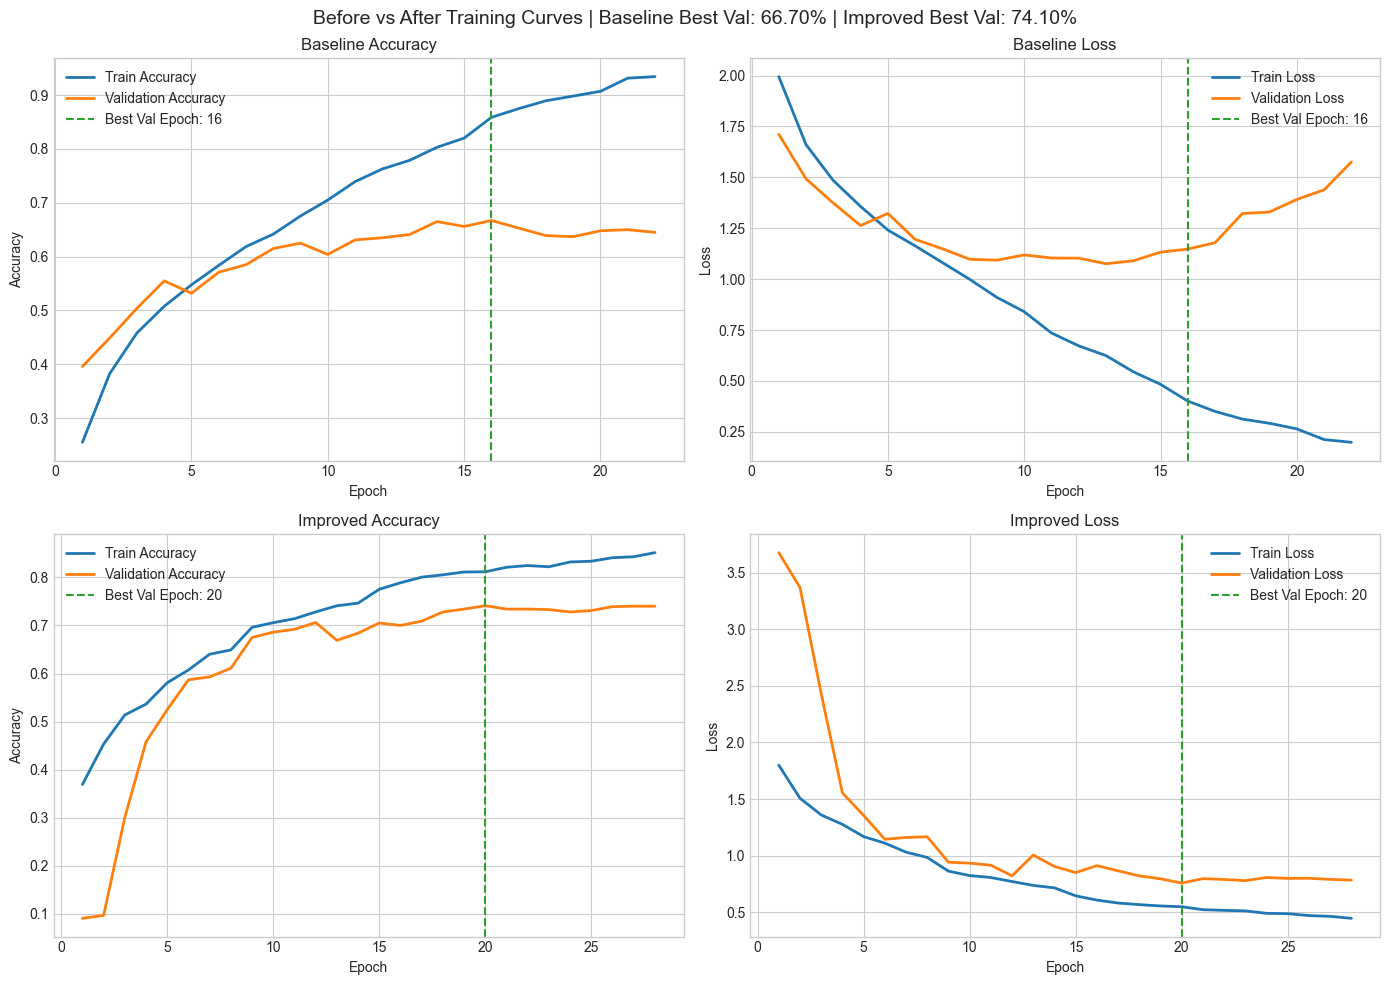

Baseline best validation accuracy: 66.70% at epoch 16
Improved best validation accuracy: 74.10% at epoch 20
Interpretation tip: use the test accuracy delta from the previous cell as the final before-vs-after quality check.


In [62]:
# Plot baseline vs improved histories for transparent before-vs-after comparison.
import matplotlib.pyplot as plt

baseline_data = baseline_history.history
improved_data = improved_history.history

base_epochs = range(1, len(baseline_data["accuracy"]) + 1)
imp_epochs = range(1, len(improved_data["accuracy"]) + 1)

base_best_epoch = int(np.argmax(baseline_data["val_accuracy"])) + 1
imp_best_epoch = int(np.argmax(improved_data["val_accuracy"])) + 1
base_best_val = baseline_data["val_accuracy"][base_best_epoch - 1]
imp_best_val = improved_data["val_accuracy"][imp_best_epoch - 1]

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(base_epochs, baseline_data["accuracy"], label="Train Accuracy", linewidth=2)
axes[0, 0].plot(base_epochs, baseline_data["val_accuracy"], label="Validation Accuracy", linewidth=2)
axes[0, 0].axvline(base_best_epoch, color="tab:green", linestyle="--", label=f"Best Val Epoch: {base_best_epoch}")
axes[0, 0].set_title("Baseline Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend()

axes[0, 1].plot(base_epochs, baseline_data["loss"], label="Train Loss", linewidth=2)
axes[0, 1].plot(base_epochs, baseline_data["val_loss"], label="Validation Loss", linewidth=2)
axes[0, 1].axvline(base_best_epoch, color="tab:green", linestyle="--", label=f"Best Val Epoch: {base_best_epoch}")
axes[0, 1].set_title("Baseline Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()

axes[1, 0].plot(imp_epochs, improved_data["accuracy"], label="Train Accuracy", linewidth=2)
axes[1, 0].plot(imp_epochs, improved_data["val_accuracy"], label="Validation Accuracy", linewidth=2)
axes[1, 0].axvline(imp_best_epoch, color="tab:green", linestyle="--", label=f"Best Val Epoch: {imp_best_epoch}")
axes[1, 0].set_title("Improved Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()

axes[1, 1].plot(imp_epochs, improved_data["loss"], label="Train Loss", linewidth=2)
axes[1, 1].plot(imp_epochs, improved_data["val_loss"], label="Validation Loss", linewidth=2)
axes[1, 1].axvline(imp_best_epoch, color="tab:green", linestyle="--", label=f"Best Val Epoch: {imp_best_epoch}")
axes[1, 1].set_title("Improved Loss")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].legend()

fig.suptitle(
    "Before vs After Training Curves | "
    f"Baseline Best Val: {base_best_val * 100:.2f}% | Improved Best Val: {imp_best_val * 100:.2f}%",
    fontsize=14,
 )
plt.tight_layout()
plt.show()

print(f"Baseline best validation accuracy: {base_best_val * 100:.2f}% at epoch {base_best_epoch}")
print(f"Improved best validation accuracy: {imp_best_val * 100:.2f}% at epoch {imp_best_epoch}")
print("Interpretation tip: use the test accuracy delta from the previous cell as the final before-vs-after quality check.")